# Brainhack · Notebook 0: set up your computer

Brainhack Montréal, autumn 2026 · *Do foundation models beat classical EEG decoding?*

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/BabaSanfour/meeg-fm-workshop/blob/main/00_setup.ipynb)

<table style="width:100%; border-collapse:separate; border-spacing:0; margin:6px 0 10px 0;"><tr><td style="background:#0B2545; color:#FFFFFF; padding:10px 14px; border:3px solid #FFFFFF; border-radius:8px; vertical-align:top; width:33%;"><div style="font-size:0.8em; color:#C9D6E8;">NOTEBOOK 0</div><div style="font-weight:bold; font-size:1.05em; color:#FFFFFF;">Setup</div><div style="font-size:0.85em; color:#C9D6E8;">check · install · download</div></td><td style="background:#EEF3F9; color:#0B2545; padding:10px 14px; border:3px solid #FFFFFF; border-radius:8px; vertical-align:top; width:33%;"><div style="font-size:0.8em; color:#5B6472;">NOTEBOOK 1</div><div style="font-weight:bold; font-size:1.05em; color:#0B2545;">Meet the data</div><div style="font-size:0.85em; color:#5B6472;">BCI IV 2a · epochs · mu and beta rhythms</div></td><td style="background:#EEF3F9; color:#0B2545; padding:10px 14px; border:3px solid #FFFFFF; border-radius:8px; vertical-align:top; width:33%;"><div style="font-size:0.8em; color:#5B6472;">NOTEBOOK 2</div><div style="font-weight:bold; font-size:1.05em; color:#0B2545;">Classical baselines</div><div style="font-size:0.85em; color:#5B6472;">CSP + LDA · tangent space</div></td></tr><tr><td style="background:#EEF3F9; color:#0B2545; padding:10px 14px; border:3px solid #FFFFFF; border-radius:8px; vertical-align:top; width:33%;"><div style="font-size:0.8em; color:#5B6472;">NOTEBOOK 3</div><div style="font-weight:bold; font-size:1.05em; color:#0B2545;">Frozen REVE</div><div style="font-size:0.85em; color:#5B6472;">embeddings · linear probe · few labels</div></td><td style="background:#EEF3F9; color:#0B2545; padding:10px 14px; border:3px solid #FFFFFF; border-radius:8px; vertical-align:top; width:33%;"><div style="font-size:0.8em; color:#5B6472;">NOTEBOOK 4</div><div style="font-weight:bold; font-size:1.05em; color:#0B2545;">Fine-tuning</div><div style="font-size:0.85em; color:#5B6472;">demo · GPU optional</div></td><td style="background:#EEF3F9; color:#0B2545; padding:10px 14px; border:3px solid #FFFFFF; border-radius:8px; vertical-align:top; width:33%;"><div style="font-size:0.8em; color:#5B6472;">NOTEBOOK 5</div><div style="font-weight:bold; font-size:1.05em; color:#0B2545;">Who won?</div><div style="font-size:0.85em; color:#5B6472;">one table · per person · statistics</div></td></tr></table>

The tutorial asks one question: on the same EEG, the same labels and the same train/test split, does a large pretrained model decode better than the classical methods? Notebook 1 looks at the data, notebook 2 builds two classical decoders, notebooks 3 and 4 use the pretrained model REVE, and notebook 5 compares them.

This notebook gets your computer ready. It checks your setup, downloads **BCI Competition IV 2a** (about 780 MB) and loads the **REVE embeddings** used from notebook 3 on. Run it once with *Run all*: about 5 minutes, mostly downloads.

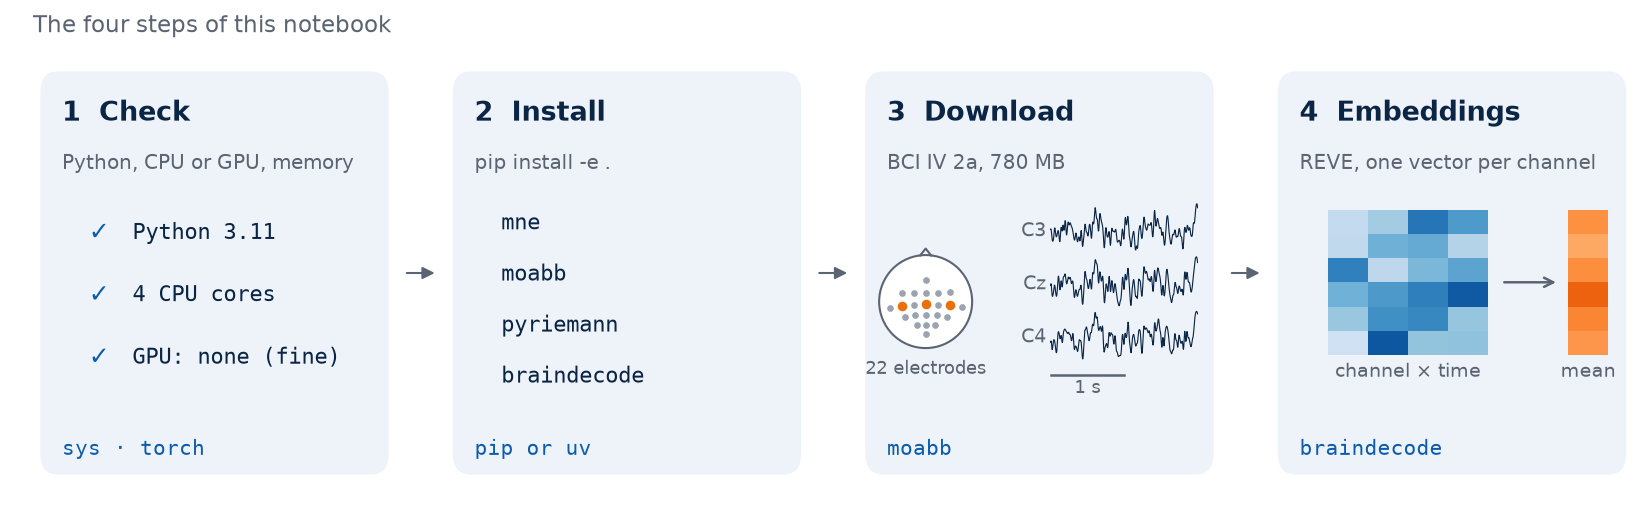

<details><summary>Colab or your own computer?</summary>

**Colab** (nothing to install): open the repository on GitHub, click the *Open in Colab* badge of `00_setup.ipynb`, then *Runtime › Run all*. The first cell installs the tutorial package (1 to 2 minutes) and asks to connect your Google Drive: each Colab notebook runs on its own machine, and Drive is where the data waits for the next notebook.

**Your computer**:
```bash
git clone https://github.com/BabaSanfour/meeg-fm-workshop.git
cd meeg-fm-workshop
pip install -e .                       # or, with uv: uv venv && uv pip install -e .
```
On Linux without a GPU, install the smaller CPU-only PyTorch first: `pip install torch --index-url https://download.pytorch.org/whl/cpu` (with uv: `uv pip install -e . --torch-backend cpu`).
Then open `00_setup.ipynb` in VS Code (choose the Python environment you just installed into as the kernel), or install Jupyter with `pip install -e ".[jupyter]"` and run `jupyter lab`.
</details>

In [1]:
# ---- Install (Colab only), imports and data folder
import sys
import importlib

REPO_URL = "https://github.com/BabaSanfour/meeg-fm-workshop"   # the tutorial repository
USE_DRIVE = True                                     # Colab: keep the data in your Google Drive between notebooks

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    !pip install -q "git+{REPO_URL}.git"
    if USE_DRIVE:
        from google.colab import drive
        drive.mount("/content/drive")                # a window asks for permission
    importlib.invalidate_caches()

try:
    import brainhack_eegfm as be                     # the tutorial package: helpers + cached embeddings
except ImportError:
    raise ImportError("The tutorial package is missing. Colab: Runtime › Restart session, then Run all. "
                      "Your computer: run `pip install -e .` in the repository folder, then restart the kernel.")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne

mne.set_log_level("WARNING")                         # MNE only prints warnings
DATA_DIR = be.use_data_dir()                         # one folder for every notebook
print("Tutorial package", be.__version__, "| MNE", mne.__version__)
print("Data folder:", DATA_DIR)

Tutorial package 0.1.0 | MNE 1.13.2
Data folder: ~/mne_data


### Parameters

On a slow or crowded Wi-Fi, keep three participants and skip the REVE check. The rest still works.

In [2]:
# ---- Parameters
SUBJECTS = list(range(1, 10))   # the 9 participants, about 780 MB (slow connection: [1, 2, 3])
CHECK_REVE = True               # download REVE (280 MB) and compare it with the cache (slow connection: False)
REPORT = []                     # one line per part, printed in the summary

## 1. Check your computer

A laptop processor (CPU) is enough. A GPU is only needed if you want to redo the fine-tuning of notebook 4, whose results are saved in advance.

In [3]:
# ---- What does this computer have?
import os
import platform
import shutil
import torch


def memory_gb():
    """Total memory in GB, or None if the system does not say (Windows)."""
    try:
        return os.sysconf("SC_PAGE_SIZE") * os.sysconf("SC_PHYS_PAGES") / 1e9
    except (ValueError, AttributeError, OSError):
        return None


if torch.cuda.is_available():
    gpu = torch.cuda.get_device_name(0)
elif torch.backends.mps.is_available():
    gpu = "Apple GPU (mps)"
else:
    gpu = "none"
ram = memory_gb()
free_gb = shutil.disk_usage(DATA_DIR).free / 1e9

computer = pd.DataFrame([
    ("Python", platform.python_version(), sys.version_info >= (3, 10), "3.10 or newer"),
    ("Running on", "Colab" if IN_COLAB else platform.system(), True, "Colab, Linux, macOS or Windows"),
    ("CPU cores", os.cpu_count(), True, "more is faster"),
    ("Memory", f"{ram:.0f} GB" if ram else "unknown", ram is None or ram >= 4, "4 GB or more"),
    ("GPU", gpu, True, "optional (notebook 4 only)"),
    ("Free disk", f"{free_gb:.0f} GB", free_gb >= 2, "2 GB for the data"),
], columns=["check", "value", "ok", "needed"]).set_index("check")
REPORT.append(("Computer", bool(computer["ok"].all()), "see the table in part 1"))
computer

,value,ok,needed
check,,,
Python,3.12.10,True,3.10 or newer
Running on,Darwin,True,"Colab, Linux, macOS or Windows"
CPU cores,8,True,more is faster
Memory,17 GB,True,4 GB or more
GPU,Apple GPU (mps),True,optional (notebook 4 only)
Free disk,129 GB,True,2 GB for the data


Every line of the `ok` column should read `True`; `GPU: none` is fine. With less than 4 GB of memory, set `SUBJECTS = [1, 2, 3]` in the parameters.

## 2. Check the tools

`pip install -e .` installed the tutorial's helper code and the libraries it uses: [MNE-Python](https://mne.tools), [MOABB](https://moabb.neurotechx.com), [pyRiemann](https://pyriemann.readthedocs.io), [Braindecode](https://braindecode.org), PyTorch and scikit-learn. This cell checks that each one is installed and recent enough.

In [4]:
# ---- Is each tool installed, and recent enough?
from importlib.metadata import PackageNotFoundError, version
from packaging.version import Version

NEEDED = {"brainhack-eegfm": "0.1", "mne": "1.10", "moabb": "1.2", "pyriemann": "0.7",
          "braindecode": "1.8.1", "torch": "2.2", "scikit-learn": "1.6", "numpy": "2.0"}

rows = []
for name, minimum in NEEDED.items():
    try:
        installed = version(name)
    except PackageNotFoundError:
        installed = None
    rows.append((name, installed or "missing", minimum, installed is not None and Version(installed) >= Version(minimum)))
tools = pd.DataFrame(rows, columns=["package", "installed", "minimum", "ok"]).set_index("package")
REPORT.append(("Tools", bool(tools["ok"].all()), "`pip install -e .` again, restart the kernel"))
tools

,installed,minimum,ok
package,,,
brainhack-eegfm,0.1.0,0.1,True
mne,1.13.2,1.10,True
moabb,1.7.2,1.2,True
pyriemann,0.12,0.7,True
braindecode,1.8.1,1.8.1,True
torch,2.14.1,2.2,True
scikit-learn,1.9.1,1.6,True
numpy,2.5.3,2.0,True


## 3. Download BCI IV 2a

MOABB downloads two files per participant into the data folder printed above: 18 files, about 780 MB (Tangermann et al., 2012; licence CC BY-ND 4.0). It takes about a minute on a fast connection. If the download stops, run the cell again: finished files are kept.

In [5]:
# ---- Download the raw recordings (files already on disk are skipped)
start = time.time()
downloaded = be.download(SUBJECTS)
print(f"{len(SUBJECTS)} participants, {downloaded['MB'].sum():.0f} MB on disk, {time.time() - start:.0f} s")
REPORT.append(("Data", all(be.is_downloaded(s) for s in SUBJECTS), "run part 3 again; finished files are kept"))
downloaded.T

9 participants, 780 MB on disk, 5 s


subject,1,2,3,4,5,6,7,8,9
MB,87.0,87.0,86.0,79.0,87.0,88.0,85.0,91.0,90.0
seconds,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### Load one participant

A quick check that the files can be read: the left- and right-hand trials of participant 1.

In [6]:
# ---- Participant 1, all left- and right-hand trials
X, y, meta = be.load_epochs([1], fmin=1, fmax=40)
print("X:", X.shape, "(trials, channels, samples)")
print("Classes:", pd.Series(y).value_counts().to_dict())
print("Days:", meta["session"].value_counts().to_dict())

X: (288, 22, 1000) (trials, channels, samples)
Classes: {'right_hand': 144, 'left_hand': 144}
Days: {'0train': 144, '1test': 144}


You should see 288 trials of 22 channels × 1000 samples.

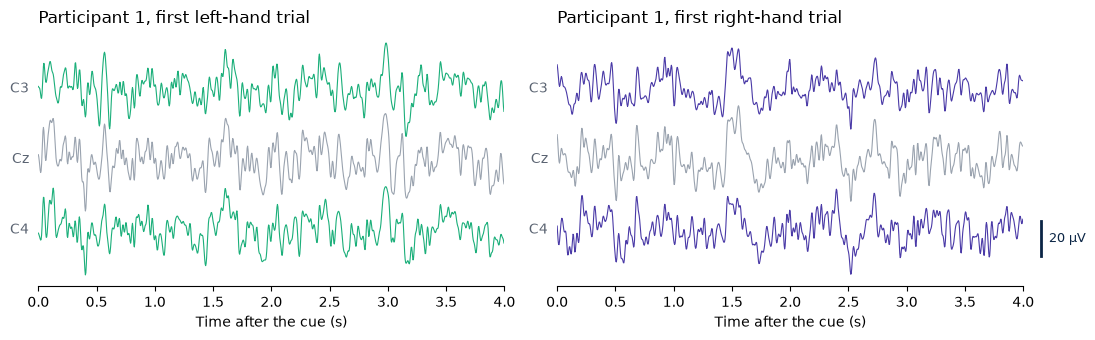

In [7]:
# ---- One left-hand and one right-hand trial over the motor cortex
COLORS = {"left_hand": "#1baf7a", "right_hand": "#4a3aa7"}
SFREQ = 250
times = np.arange(X.shape[-1]) / SFREQ

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), sharey=True)
for ax, cls in zip(axes, COLORS):
    trial = np.flatnonzero(y == cls)[0]                       # the first trial of this class
    for k, ch in enumerate(["C3", "Cz", "C4"]):
        color = "#9AA3AF" if ch == "Cz" else COLORS[cls]
        ax.plot(times, X[trial, be.CHANNELS.index(ch)] - 40 * k, color=color, lw=0.8)
        ax.text(-0.08, -40 * k, ch, ha="right", va="center", color="#5B6472")
    ax.set_title(f"Participant 1, first {cls.replace('_', '-')} trial", loc="left")
    ax.set_xlabel("Time after the cue (s)")
    ax.set_yticks([])
    ax.spines[["top", "right", "left"]].set_visible(False)
for ax in axes:
    ax.set_xlim(0, 4)
axes[1].plot([4.15, 4.15], [-95, -75], color="#0B2545", lw=2, clip_on=False)   # scale bar
axes[1].text(4.22, -85, "20 µV", va="center", fontsize=9, color="#0B2545")
plt.tight_layout()
plt.show()

If each panel shows three noisy traces, the data is fine. Notebook 1 explains what is in them.

## 4. REVE embeddings

REVE is the pretrained model of notebooks 3 and 4. Running it on every trial takes a few minutes, so its output (the *embeddings*) comes with the package: 9 files of 6 MB. This cell reads them and checks that they match the trials loaded above.

In [8]:
# ---- Read the embeddings shipped with the package
missing = be.missing_from_cache(be.SUBJECTS)
if missing:                                   # only if your copy of the package lacks some files
    be.build_embedding_cache(missing)         # about 15 s per participant, saved in the data folder
emb = be.load_embedding_cache(be.SUBJECTS)
print("X:", emb["X"].shape, "(trials, channels, 512 numbers)")
print("Made with:", emb["info"]["model"], "| Braindecode", emb["info"]["braindecode"])

same_trials = np.array_equal(emb["y"][emb["subject"] == 1], y)   # same order as the raw trials above?
print("Participant 1, same trials in the same order as the raw data:", same_trials)
REPORT.append(("Embeddings", same_trials and not be.missing_from_cache(be.SUBJECTS), "run be.build_embedding_cache()"))

X: (2592, 22, 512) (trials, channels, 512 numbers)
Made with: brain-bzh/reve-base | Braindecode 1.8.1
Participant 1, same trials in the same order as the raw data: True


### Check REVE itself

This cell downloads REVE's weights (280 MB, reused in notebooks 3 and 4), runs the model on 16 trials and compares the result with the shipped embeddings. On a slow connection, set `CHECK_REVE = False`: notebook 3 does not need it.

In [9]:
# ---- Run REVE on 16 trials and compare with the cache
if CHECK_REVE:
    info = emb["info"]
    X200, _, _ = be.load_epochs([1], sfreq=info["sfreq"], fmin=info["band_hz"][0], fmax=info["band_hz"][1])
    start = time.time()
    model = be.load_reve(be.CHANNELS, X200.shape[-1])
    fresh = be.embed(X200[:16], be.CHANNELS, model=model, progress=False)
    cached = emb["X"][emb["subject"] == 1][:16]
    r = np.corrcoef(fresh.ravel(), cached.ravel())[0, 1]
    n_params = sum(p.numel() for p in model.parameters()) / 1e6
    print(f"REVE: {n_params:.0f} M parameters, downloaded, loaded and run in {time.time() - start:.0f} s")
    print(f"Fresh vs cached embeddings: correlation {r:.4f}, largest difference {np.abs(fresh - cached).max():.3f}")
    REPORT.append(("REVE", bool(r > 0.99), "rerun this cell; notebook 3 works without it"))
else:
    print("Skipped: notebook 3 uses the cache.")

REVE: 69 M parameters, downloaded, loaded and run in 2 s
Fresh vs cached embeddings: correlation 1.0000, largest difference 0.016


A correlation of 0.99 or more means REVE gives the same numbers on your machine as in the shipped files.

## 5. Summary

In [10]:
# ---- One line per part
summary = pd.DataFrame(REPORT, columns=["part", "ok", "if not"]).set_index("part")
summary["ok"] = summary["ok"].map({True: "✓", False: "✗"})
summary

,ok,if not
part,,
Computer,✓,see the table in part 1
Tools,✓,"`pip install -e .` again, restart the kernel"
Data,✓,run part 3 again; finished files are kept
Embeddings,✓,run be.build_embedding_cache()
REVE,✓,rerun this cell; notebook 3 works without it


Every line should show ✓. If one shows ✗, the `if not` column says what to run again.

**Next**: `01_data.ipynb`.

<details><summary>References</summary>

- El Ouahidi, Y., Lys, J., Thölke, P., Farrugia, N., Pasdeloup, B., Gripon, V., Jerbi, K., & Lioi, G. (2025). REVE: A foundation model for EEG, adapting to any setup with large-scale pretraining on 25,000 subjects. *Advances in Neural Information Processing Systems 38*. https://arxiv.org/abs/2510.21585
- Tangermann, M., Müller, K.-R., Aertsen, A., Birbaumer, N., Braun, C., Brunner, C., ... Blankertz, B. (2012). Review of the BCI Competition IV. *Frontiers in Neuroscience, 6*, 55. https://doi.org/10.3389/fnins.2012.00055
</details>